In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Wed Aug 27 05:36:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.76.05              Driver Version: 580.76.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:19:00.0 Off |                  Off |
| 69%   79C    P2            250W /  250W |   20173MiB /  24564MiB |     95%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-27 05:36:06.673860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/scpark/miniconda3/envs/rbf/lib/python3.11

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


In [5]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
#class_start = 0
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
noises = model.get_noise(seeds=class_ids)


In [11]:
!ls logs/dit/bns/s3

events.out.tfevents.1756238196.scpark-X299-WU8.37033.0	step_00000578.pt
step_00000034.pt					step_00000612.pt
step_00000068.pt					step_00000646.pt
step_00000102.pt					step_00000680.pt
step_00000136.pt					step_00000714.pt
step_00000170.pt					step_00000748.pt
step_00000204.pt					step_00000782.pt
step_00000238.pt					step_00000816.pt
step_00000272.pt					step_00000850.pt
step_00000306.pt					step_00000884.pt
step_00000340.pt					step_00000918.pt
step_00000374.pt					step_00000952.pt
step_00000408.pt					step_00000986.pt
step_00000442.pt					step_00001020.pt
step_00000476.pt					step_00001054.pt
step_00000510.pt					step_00001088.pt
step_00000544.pt


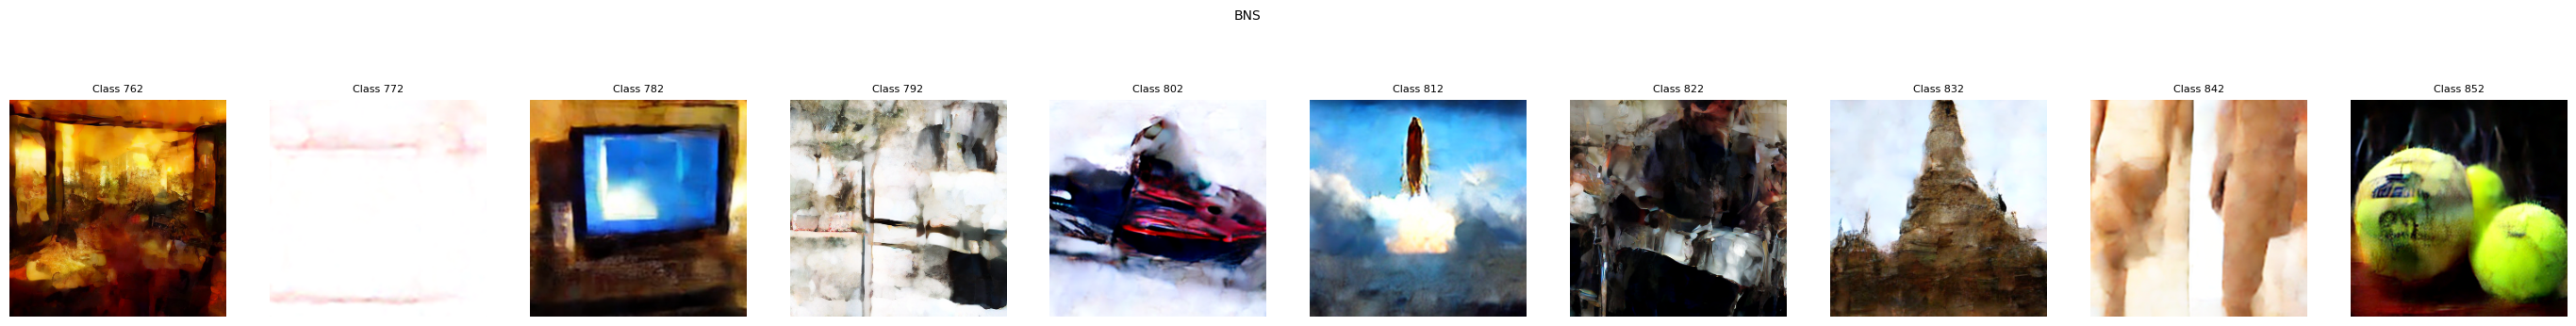

In [14]:
import numpy as np
import torch
import time

from solvers.competing.bns.bns_solver import BNS_Solver

noise_schedule = model.get_noise_schedule()
solver = BNS_Solver(
        noise_schedule,
        steps=3,
        skip_type="time_uniform",
    ).to(model.device)

pt_file = 'logs/dit/bns/s3/step_00001088.pt'
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='BNS')


In [45]:
solver.a

Parameter containing:
tensor([1.0116, 1.0504, 1.0063, 1.0490, 1.2066], device='cuda:0',
       requires_grad=True)

In [9]:
solver.b

Parameter containing:
tensor([[0.9907, 0.9990, 0.9990, 0.9990, 0.9990],
        [0.9807, 0.9878, 0.9990, 0.9990, 0.9990],
        [0.9821, 0.9790, 0.9819, 0.9990, 0.9990],
        [0.9731, 0.9806, 0.9872, 1.0131, 0.9990],
        [1.0280, 0.9670, 0.9388, 0.9437, 0.9485]], device='cuda:0',
       requires_grad=True)